# **Data Ingestion, Cleaning & Preprocessing with Pandas**

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [4]:
# Load the dataset
df = pd.read_csv(
    "Data Ingestion Cleaning dataset.csv",
    encoding="latin1"
)


In [5]:
# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
# Dataset information

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 9994
Number of columns: 21

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [7]:
# Statistical summary of numerical columns

df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
# Missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_summary)

,Missing Count,Missing Percentage
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Customer Name,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0


In [10]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Display duplicate records
duplicates = df[df.duplicated(keep=False)]

print("\nDuplicate records:")
display(duplicates)

Number of duplicate rows: 0

Duplicate records:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [11]:
# Check current data types

print("Current data types:")
print(df.dtypes)# Check current data types

print("Current data types:")
print(df.dtypes)

Current data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Current data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      obj

In [12]:
# Check important columns individually

print("Order Date type:", df["Order Date"].dtype)
print("Ship Date type:", df["Ship Date"].dtype)
print("Sales type:", df["Sales"].dtype)
print("Quantity type:", df["Quantity"].dtype)
print("Discount type:", df["Discount"].dtype)
print("Profit type:", df["Profit"].dtype)

Order Date type: object
Ship Date type: object
Sales type: float64
Quantity type: int64
Discount type: float64
Profit type: float64


In [13]:
# Check categorical columns for inconsistent values

categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country",
    "Region",
    "Category",
    "Sub-Category"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Ship Mode ---
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

--- Segment ---
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

--- Country ---
Country
United States    9994
Name: count, dtype: int64

--- Region ---
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

--- Category ---
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

--- Sub-Category ---
Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64


In [14]:
# Create a copy of the raw dataset for cleaning

clean_df = df.copy()

print("Raw dataset shape:", df.shape)
print("Cleaning dataset shape:", clean_df.shape)

Raw dataset shape: (9994, 21)
Cleaning dataset shape: (9994, 21)


In [15]:
# Count duplicates before cleaning

duplicates_before = clean_df.duplicated().sum()

print("Duplicate rows before cleaning:", duplicates_before)

# Remove duplicate rows
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after cleaning:", clean_df.duplicated().sum())
print("New dataset shape:", clean_df.shape)

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0
New dataset shape: (9994, 21)


In [16]:
# Convert date columns to datetime

clean_df["Order Date"] = pd.to_datetime(
    clean_df["Order Date"],
    errors="coerce"
)

clean_df["Ship Date"] = pd.to_datetime(
    clean_df["Ship Date"],
    errors="coerce"
)

# Check the result
print("Order Date type:", clean_df["Order Date"].dtype)
print("Ship Date type:", clean_df["Ship Date"].dtype)

Order Date type: datetime64[ns]
Ship Date type: datetime64[ns]


In [17]:
# Convert numerical columns to numeric data types

numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

for col in numeric_columns:
    clean_df[col] = pd.to_numeric(
        clean_df[col],
        errors="coerce"
    )

# Check data types
print(clean_df[numeric_columns].dtypes)

Sales       float64
Quantity      int64
Discount    float64
Profit      float64
dtype: object


In [18]:
# Check missing values in the cleaned dataset

missing_after_conversion = clean_df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Count": missing_after_conversion,
    "Missing Percentage": (
        missing_after_conversion / len(clean_df) * 100
    ).round(2)
})

display(missing_summary)

,Missing Count,Missing Percentage
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Customer Name,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0


In [19]:
# Handle missing values

# Numeric columns
numeric_columns = ["Sales", "Quantity", "Discount", "Profit"]

for col in numeric_columns:
    if clean_df[col].isnull().sum() > 0:
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Categorical columns
categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country",
    "City",
    "State",
    "Postal Code",
    "Region",
    "Category",
    "Sub-Category"
]

for col in categorical_columns:
    if clean_df[col].isnull().sum() > 0:
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

# Date columns
date_columns = ["Order Date", "Ship Date"]

for col in date_columns:
    if clean_df[col].isnull().sum() > 0:
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

print("Missing values handled.")

Missing values handled.


In [20]:
# Verify remaining missing values

remaining_missing = clean_df.isnull().sum()

print("Remaining missing values:")
print(remaining_missing[remaining_missing > 0])

print("\nTotal remaining missing values:",
      clean_df.isnull().sum().sum())

Remaining missing values:
Series([], dtype: int64)

Total remaining missing values: 0


In [21]:
# ============================================================
# OUTLIER DETECTION USING IQR
# ============================================================

outlier_summary = []

for col in ["Sales", "Quantity", "Discount", "Profit"]:

    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = clean_df[
        (clean_df[col] < lower_bound) |
        (clean_df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Column,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,Sales,17.28000,209.940,-271.710000,498.930000,1167
1,Quantity,2.00000,5.000,-2.500000,9.500000,170
2,Discount,0.00000,0.200,-0.300000,0.500000,856
3,Profit,1.72875,29.364,-39.724125,70.816875,1881


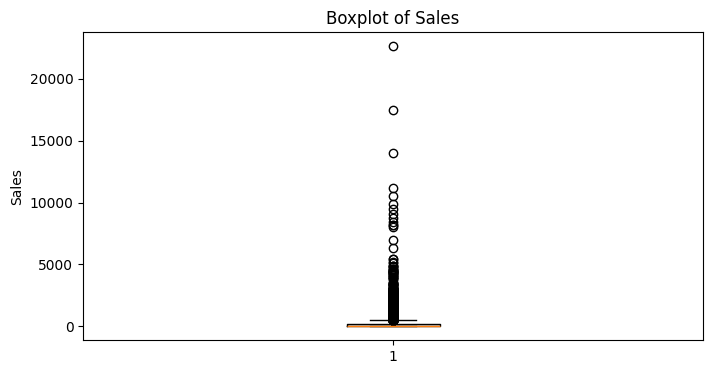

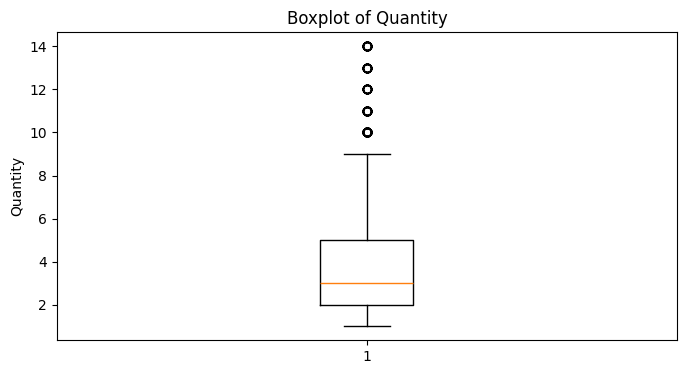

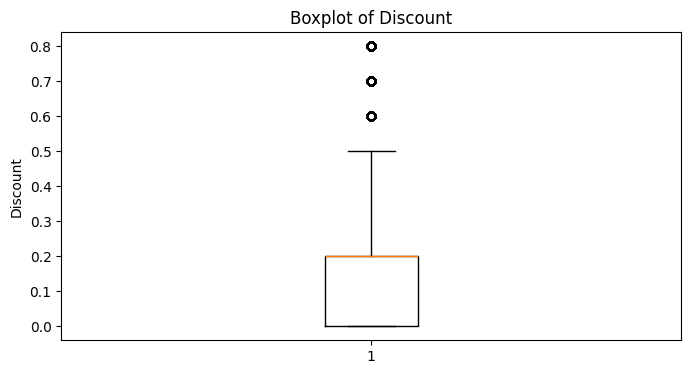

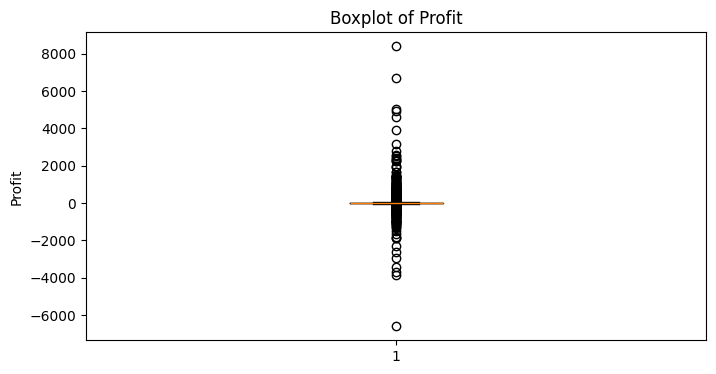

In [22]:
# ============================================================
# OUTLIER VISUALIZATION
# ============================================================

for col in ["Sales", "Quantity", "Discount", "Profit"]:

    plt.figure(figsize=(8, 4))
    plt.boxplot(clean_df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [23]:
# ============================================================
# CAP EXTREME OUTLIERS USING IQR
# ============================================================

for col in ["Sales", "Quantity", "Discount", "Profit"]:

    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clean_df[col] = clean_df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Extreme outliers have been capped using the IQR method.")

Extreme outliers have been capped using the IQR method.


In [24]:
# ============================================================
# STANDARDIZE CATEGORICAL VALUES
# ============================================================

categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country",
    "City",
    "State",
    "Region",
    "Category",
    "Sub-Category"
]

for col in categorical_columns:
    clean_df[col] = (
        clean_df[col]
        .astype(str)
        .str.strip()
    )

print("Categorical values standardized.")

Categorical values standardized.


In [25]:
# Check unique values after standardization

for col in ["Ship Mode", "Segment", "Region", "Category"]:
    print(f"\n{col}:")
    print(clean_df[col].unique())


Ship Mode:
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Segment:
['Consumer' 'Corporate' 'Home Office']

Region:
['South' 'West' 'Central' 'East']

Category:
['Furniture' 'Office Supplies' 'Technology']


In [26]:
# Create Year feature

clean_df["Order Year"] = clean_df["Order Date"].dt.year

print(clean_df[["Order Date", "Order Year"]].head())

  Order Date  Order Year
0 2016-11-08        2016
1 2016-11-08        2016
2 2016-06-12        2016
3 2015-10-11        2015
4 2015-10-11        2015


In [27]:
# Create Month feature

clean_df["Order Month"] = clean_df["Order Date"].dt.month

print(clean_df[["Order Date", "Order Month"]].head())

  Order Date  Order Month
0 2016-11-08           11
1 2016-11-08           11
2 2016-06-12            6
3 2015-10-11           10
4 2015-10-11           10


In [28]:
# Create Month Name feature

clean_df["Order Month Name"] = clean_df["Order Date"].dt.month_name()

print(clean_df[[
    "Order Date",
    "Order Month",
    "Order Month Name"
]].head())

  Order Date  Order Month Order Month Name
0 2016-11-08           11         November
1 2016-11-08           11         November
2 2016-06-12            6             June
3 2015-10-11           10          October
4 2015-10-11           10          October


In [29]:
# Create Profit Margin feature

clean_df["Profit Margin (%)"] = np.where(
    clean_df["Sales"] != 0,
    (clean_df["Profit"] / clean_df["Sales"]) * 100,
    0
)

print(clean_df[[
    "Sales",
    "Profit",
    "Profit Margin (%)"
]].head())

     Sales     Profit  Profit Margin (%)
0  261.960  41.913600          16.000000
1  498.930  70.816875          14.193750
2   14.620   6.871400          47.000000
3  498.930 -39.724125          -7.961863
4   22.368   2.516400          11.250000


In [30]:
# Create Shipping Days feature

clean_df["Shipping Days"] = (
    clean_df["Ship Date"] - clean_df["Order Date"]
).dt.days

print(clean_df[[
    "Order Date",
    "Ship Date",
    "Shipping Days"
]].head())

  Order Date  Ship Date  Shipping Days
0 2016-11-08 2016-11-11              3
1 2016-11-08 2016-11-11              3
2 2016-06-12 2016-06-16              4
3 2015-10-11 2015-10-18              7
4 2015-10-11 2015-10-18              7


In [31]:
# ============================================================
# BEFORE VS AFTER CLEANING
# ============================================================

print("BEFORE CLEANING")
print("----------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

print("\nAFTER CLEANING")
print("---------------")
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])
print("Duplicate rows:", clean_df.duplicated().sum())
print("Missing values:", clean_df.isnull().sum().sum())

BEFORE CLEANING
----------------
Rows: 9994
Columns: 21
Duplicate rows: 0
Missing values: 0

AFTER CLEANING
---------------
Rows: 9994
Columns: 26
Duplicate rows: 0
Missing values: 0


In [32]:
# ============================================================
# FINAL DATA VALIDATION
# ============================================================

print("FINAL DATASET VALIDATION")
print("========================")

# Check duplicates
print("Duplicate rows:", clean_df.duplicated().sum())

# Check missing values
print("Total missing values:", clean_df.isnull().sum().sum())

# Check data types
print("\nData types:")
print(clean_df.dtypes)

# Check negative quantity
print(
    "\nNegative quantities:",
    (clean_df["Quantity"] < 0).sum()
)

# Check invalid discount
print(
    "Invalid discounts:",
    ((clean_df["Discount"] < 0) | (clean_df["Discount"] > 100)).sum()
)

# Check profit margin
print(
    "Profit Margin calculated:",
    "Profit Margin (%)" in clean_df.columns
)

# Check feature engineering
print(
    "Order Year calculated:",
    "Order Year" in clean_df.columns
)

print(
    "Order Month calculated:",
    "Order Month" in clean_df.columns
)

print(
    "Shipping Days calculated:",
    "Shipping Days" in clean_df.columns
)

FINAL DATASET VALIDATION
Duplicate rows: 0
Total missing values: 0

Data types:
Row ID                        int64
Order ID                     object
Order Date           datetime64[ns]
Ship Date            datetime64[ns]
Ship Mode                    object
Customer ID                  object
Customer Name                object
Segment                      object
Country                      object
City                         object
State                        object
Postal Code                   int64
Region                       object
Product ID                   object
Category                     object
Sub-Category                 object
Product Name                 object
Sales                       float64
Quantity                    float64
Discount                    float64
Profit                      float64
Order Year                    int32
Order Month                   int32
Order Month Name             object
Profit Margin (%)           float64
Shipping Days       

In [33]:
# Display final cleaned dataset

display(clean_df.head(10))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Profit Margin (%),Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.960,2.0,0.00,41.913600,2016,11,November,16.000000,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",498.930,3.0,0.00,70.816875,2016,11,November,14.193750,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.620,2.0,0.00,6.871400,2016,6,June,47.000000,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,498.930,5.0,0.45,-39.724125,2015,10,October,-7.961863,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.368,2.0,0.20,2.516400,2015,10,October,11.250000,7
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Eldon Expressions Wood and Plastic Desk Access...,48.860,7.0,0.00,14.169400,2014,6,June,29.000000,5
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Newell 322,7.280,4.0,0.00,1.965600,2014,6,June,27.000000,5
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Mitel 5320 IP Phone VoIP phone,498.930,6.0,0.20,70.816875,2014,6,June,14.193750,5
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,DXL Angle-View Binders with Locking Rings by S...,18.504,3.0,0.20,5.782500,2014,6,June,31.250000,5
9,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Belkin F5C206VTEL 6 Outlet Surge,114.900,5.0,0.00,34.470000,2014,6,June,30.000000,5


In [34]:
print("Final dataset shape:", clean_df.shape)

Final dataset shape: (9994, 26)


In [35]:
# ============================================================
# EXPORT CLEAN DATASET
# ============================================================

output_file = "clean_dataset.csv"

clean_df.to_csv(
    output_file,
    index=False
)

print(f"Clean dataset exported successfully as: {output_file}")

Clean dataset exported successfully as: clean_dataset.csv
